# Coin Detection, Classification, and Counting — Solution

*Image Processing and Computer Vision — Module #1 (Prof. Lisanti, UniBO).* Traditional CV only.

**Pipeline.** (A/B) detect coins as **Hough circles** (Summary §6.3) on Gaussian/median-smoothed
gray (§3), with a weak-rim fallback; (C) classify each coin **geometry-first**: a **bi-metal flag**
from the chroma-gradient ring (colour, §2) splits 1€/2€, and a rotation-invariant **GHT on edge
points** (§6.4) reads the digit of the rest; (D) aggregate to the brief's output format.

**Honesty note (the brief rewards a justified partial over a blind complete).** Detection and the
bi-metal flag are solid; per-denomination classification of the *mono* coins is **approximate** —
the blue specular cast + wear + low resolution defeat every appearance matcher we tried (see
`DECISIONS.md`/`Strategy.md`). Values are the pipeline's best estimate; limits are stated in §6.

## 0. Setup

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA = Path("coin_dataset"); REF, TGT = DATA / "reference_set", DATA / "target_set"

# Physical euro-coin diameters (mm) and face values.
DIAMETER_MM = {"1cent": 16.25, "2cent": 18.75, "5cent": 21.25, "10cent": 19.75,
               "20cent": 22.25, "50cent": 24.25, "1euro": 23.25, "2euro": 25.75}
VALUE_EUR   = {"1cent": 0.01, "2cent": 0.02, "5cent": 0.05, "10cent": 0.10,
               "20cent": 0.20, "50cent": 0.50, "1euro": 1.00, "2euro": 2.00}
REF_NAMES = sorted(VALUE_EUR)
MONO      = ["1cent", "2cent", "5cent", "10cent", "20cent", "50cent"]   # monometallic
BIMETAL   = ["1euro", "2euro"]

def load_rgb(path):
    bgr = cv2.imread(str(path)); assert bgr is not None, f"imread failed: {path}"
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

def show_grid(images, titles, ncols=3, figsize=None):
    n = len(images); nrows = -(-n // ncols)
    plt.figure(figsize=figsize or (4 * ncols, 4 * nrows))
    for i, (img, t) in enumerate(zip(images, titles), 1):
        plt.subplot(nrows, ncols, i)
        (plt.imshow(img, cmap="gray", vmin=0, vmax=255) if img.ndim == 2 else plt.imshow(img))
        plt.title(t, fontsize=10); plt.axis("off")
    plt.tight_layout(); plt.show()

print("cv2", cv2.__version__, "| refs", len(list(REF.glob("*.jpg"))), "| targets", len(list(TGT.glob("*.jpg"))))

cv2 4.13.0 | refs 8 | targets 142


## 1. Pre-processing — image filtering (Summary §3)

Target images carry visible noise (σ ≈ 17 vs reference ≈ 0.3). For **detection** a Gaussian/median
smooth suffices and keeps the strong coin rim. For the **appearance** cues we use **Non-Local Means**
(it removes the grain while preserving the digit/relief structure a Gaussian would destroy). Note:
denoising fights the *noise*, **not** the blue colour cast — the cast is specular and not filter-removable.

In [2]:
def nlm(gray):
    """Non-local-means denoise (Summary §3.4) — used before the appearance cues."""
    return cv2.fastNlMeansDenoising(gray, None, 12, 7, 21)

## 2. Reference models (Summary §6.1 / §6.2 / §6.4)

From the 8 labelled single-coin references we build, per denomination, two models used at
classification time:
- a **GHT edge model** — the *N* strongest-gradient points inside the coin (uniform density), with
  their gradient orientation, used to vote for a match at any rotation (§6.4 / star-model idea);
- the chroma machinery for the **bi-metal flag** is defined in §4.

The clean references localise their single coin with one Hough pass.

In [3]:
def _href(gray):
    """Locate the single coin in a clean reference image."""
    c = cv2.HoughCircles(cv2.medianBlur(gray, 5), cv2.HOUGH_GRADIENT, 1.2, 300,
                         param1=150, param2=30, minRadius=40, maxRadius=300)
    return tuple(map(int, np.round(c[0][0])))

# --- GHT edge model (fair: uniform-density templates, rotation-searched, size-normalized) ---
_GN, _GK, _GTOL, _GSTEP, _GM = 250, 18, 2, 12, 160
_gy, _gx = np.ogrid[:_GM, :_GM]
_GCIRC = ((_gx - _GM / 2) ** 2 + (_gy - _GM / 2) ** 2) <= (0.78 * _GM / 2) ** 2

def _disc(gray, cx, cy, r):
    R = int(r); return cv2.resize(gray[max(0, cy-R):cy+R, max(0, cx-R):cx+R], (_GM, _GM), interpolation=cv2.INTER_CUBIC)

def ght_edges(gray, cx, cy, r):
    """N strongest-gradient edge points (orientation 0-180) inside the circle, on the NLM-denoised disc."""
    d = _disc(nlm(gray), cx, cy, r).astype(np.float32)
    gx = cv2.Sobel(d, cv2.CV_32F, 1, 0, 3); gy = cv2.Sobel(d, cv2.CV_32F, 0, 1, 3)
    mag = np.hypot(gx, gy); mag[~_GCIRC] = 0
    idx = np.argpartition(mag.ravel(), -_GN)[-_GN:]; ys, xs = np.unravel_index(idx, mag.shape)
    return xs.astype(np.float32), ys.astype(np.float32), np.rad2deg(np.arctan2(gy[ys, xs], gx[ys, xs])) % 180

def _ght_masks(xs, ys, ori):
    m = np.zeros((_GK, _GM, _GM), np.uint8); b = (ori / (180 / _GK)).astype(int) % _GK
    m[b, ys.astype(int), xs.astype(int)] = 1; ker = np.ones((2 * _GTOL + 1, 2 * _GTOL + 1), np.uint8)
    for k in range(_GK): m[k] = cv2.dilate(m[k], ker)
    return m

def _ght_vote(model, masks):
    """Fraction of model edges that find a same-orientation target edge, at the best rotation."""
    rxs, rys, rori = model; best = 0.0
    for th in range(0, 360, _GSTEP):
        a = np.deg2rad(th); ca, sa = np.cos(a), np.sin(a)
        ix = np.round((rxs - _GM/2)*ca - (rys - _GM/2)*sa + _GM/2).astype(int)
        iy = np.round((rxs - _GM/2)*sa + (rys - _GM/2)*ca + _GM/2).astype(int)
        ok = (ix >= 0) & (ix < _GM) & (iy >= 0) & (iy < _GM); ob = ((rori + th)/(180/_GK)).astype(int) % _GK
        ixo, iyo, obo = ix[ok], iy[ok], ob[ok]
        hit = masks[obo, iyo, ixo] | masks[(obo+1) % _GK, iyo, ixo] | masks[(obo-1) % _GK, iyo, ixo]
        best = max(best, hit.sum() / _GN)
    return best

GHT_MODEL = {p.stem: ght_edges(cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2GRAY),
             *_href(cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2GRAY))) for p in sorted(REF.glob("*.jpg"))}

def ght_rank(bgr, cx, cy, r, pool):
    """Rank `pool` references by GHT vote for a target coin. Returns [(name, score), ...] desc."""
    masks = _ght_masks(*ght_edges(cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY), cx, cy, r))
    return sorted(((n, _ght_vote(GHT_MODEL[n], masks)) for n in pool), key=lambda x: -x[1])

print("GHT models built:", list(GHT_MODEL))

GHT models built: ['10cent', '1cent', '1euro', '20cent', '2cent', '2euro', '50cent', '5cent']


## 3. Detection — coins as Hough circles (Summary §6.3, §4)

The coin **rim** is an edge present at either contrast polarity, so Hough finds bright coins on dark
backgrounds and dark coins on light ones alike (a LoG blob detector seeks *dark* blobs only and drops
bright/specular coins — see `Strategy.md` DEC-5). A *mid* `minDist≈95` merges duplicate votes for one
coin without dropping touching coins, so **no custom de-duplication is needed**.

**Weak-rim limit.** ~23 % of target images have coins with soft rims that score below the
accumulator. A recall-first **overshoot + GHT-confidence gate** recovers ~21/28 of them in
controlled validation (Strategy DEC-13), but on the **full set** its precision collapses (textured
/ dark backgrounds flood the overshoot with candidates the gate cannot all reject), so it is
**disabled in production**. We keep the precision-first detector and treat the weak-rim
zero-detections as a documented limit (Sec. 6) — the brief rewards a justified partial.

**FP filter.** Clean Hough occasionally fits a circle to the gap/shadow between touching coins. Such a circle lacks a complete rim, so we drop detections with **rim-score < 0.42** (fraction of the perimeter carrying a strong radial gradient, §4). On a 15-image GT this removes FP at a cost of ≈1 real coin in 29 — safe because the clean detector only returns strong-rim coins anyway.

In [4]:
def hough_clean(bgr, min_dist=95, param2=44, rmin=45, rmax=150):
    """Precision-first detector (Summary §6.3): exact on normal images, ~0 background FP."""
    g = cv2.medianBlur(cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY), 5)
    c = cv2.HoughCircles(g, cv2.HOUGH_GRADIENT, 1.2, minDist=min_dist, param1=150,
                         param2=param2, minRadius=rmin, maxRadius=rmax)
    return [] if c is None else [tuple(map(int, np.round(x))) for x in c[0]]

def _overshoot(bgr):
    """Recall-first detector: CLAHE+median + sensitive Hough (high recall, many FP)."""
    g = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY); en = cv2.medianBlur(cv2.createCLAHE(2.0, (8, 8)).apply(g), 5)
    c = cv2.HoughCircles(en, cv2.HOUGH_GRADIENT, 1.2, minDist=85, param1=150, param2=42, minRadius=45, maxRadius=150)
    return [] if c is None else [tuple(map(int, np.round(x))) for x in c[0]]

def weak_rim_fallback(bgr, conf=0.08):
    """Explored weak-rim recovery: overshoot + GHT-confidence gate. NOT used in production --
    on the full set its precision collapses (textured/dark backgrounds make the overshoot flood
    with candidates that the gate cannot all reject), inflating counts ~3x. Kept for reference;
    in controlled validation it gives ~21/28 at ~3 FP (Strategy DEC-13)."""
    coins = []
    for (cx, cy, r) in _overshoot(bgr):
        sc = ght_rank(bgr, cx, cy, r, REF_NAMES)
        if sc[0][1] - sc[1][1] >= conf: coins.append((cx, cy, r))
    return coins

from math import pi as _PI
def rim_score(gx, gy, cx, cy, r, T=40, n=72):
    """Fraction of the circle perimeter carrying a strong radially-aligned gradient (Summary §4).
    A real coin has a near-complete rim; a Hough FP fitted to an inter-coin gap/shadow does not."""
    H, W = gx.shape; cnt = tot = 0
    for k in range(n):
        th = 2 * _PI * k / n; nx, ny = np.cos(th), np.sin(th)
        x = int(round(cx + r * nx)); y = int(round(cy + r * ny))
        if 0 <= x < W and 0 <= y < H:
            tot += 1
            if abs(gx[y, x] * nx + gy[y, x] * ny) > T: cnt += 1
    return cnt / tot if tot else 0.0

def detect_coins(bgr, rim_thr=0.42):
    """Production detector: precision-first Hough (DEC-5) + a light rim-score FP filter that drops
    circles fitted to inter-coin gaps/shadows (rim < threshold). Safe here because the clean detector
    only ever returns strong-rim coins (weak-rim coins are not detected at all -- the ~23% documented
    limit, Sec. 6), so the filter removes gap-FP without touching real coins. The weak-rim overshoot
    fallback stays disabled (it floods FP on the full set)."""
    coins = hough_clean(bgr)
    if not coins: return coins
    g = cv2.medianBlur(cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY), 5)
    gx = cv2.Sobel(g, cv2.CV_32F, 1, 0, 3); gy = cv2.Sobel(g, cv2.CV_32F, 0, 1, 3)
    return [c for c in coins if rim_score(gx, gy, *c) >= rim_thr]

## 4. Classification — geometry-first fusion (Summary §6.1 / §6.2 / §6.4, §4)

Per coin:
1. **Bi-metal flag (colour, §2).** The cast kills absolute colour, but a bi-metal coin still has a
   **chroma discontinuity** at the metal boundary (ρ≈0.70) that survives. A coin with a strong
   chroma-gradient ring is **1€/2€**, split by relative size (the larger → 2€).
2. **Number (GHT, §6.4).** Monometallic coins are read by the GHT digit model (best of the 6 mono refs).

This resolves the structural ambiguity: the digit gives the value, the bi-metal flag settles
cent-vs-euro. *Limit:* the mono digit is only ~half-right on these worn/cast targets (§6).

In [ ]:
# ============================================================================
# Section 4 — SELF-CONTAINED classification. Operating pipeline = Strategy §11.3 bis (DEC-15):
# per scene, whole-disc edge-orientation SHAPE match-% + material/bi-metal COLOUR favour +
# relative SIZE (order/same) re-rank, with a per-coin LOCALIZED BLUR on the reference disc.
# All params/utils/atlases (suffix _11 / _3b) live here and are rebuilt from the image files;
# tuned values are copied verbatim from the scale_playground notebook. Works on the DE-CAST
# target (the references stay raw) -- the de-cast brings target colour into the reference domain.
# ============================================================================

# ---- parameters: §11 base (copied verbatim) ----
CANON11     = 150
ROT_STEP11  = 1
ANGLES11    = list(range(0, 360, ROT_STEP11))
MATCH_TOL11 = 30
TAU11       = float(np.cos(2 * np.radians(MATCH_TOL11)))
NLM_REF11, GSIG_REF11 = 1, 0.3                                   # reference disc post-zoom denoise
CASTG11 = [0.745, 0.908, 0.722]; CASTO11 = [14.12, 18.38, 53.97] # target colour de-cast (B,G,R)
VALUES11 = VALUE_EUR
NAMES11  = sorted(VALUES11)
DIAM11   = DIAMETER_MM
MATERIAL11 = {'1cent': 'copper', '2cent': 'copper', '5cent': 'copper',
              '10cent': 'gold', '20cent': 'gold', '50cent': 'gold',
              '1euro': 'bimetal', '2euro': 'bimetal'}
GROUPS11 = ['copper', 'gold', 'bimetal']
TH_BI_W11, TH_BI_S11 = 0.10, 0.40                               # chroma-ring regimes (mono / borderline / bi-metal)
COLOR_FAV11, BI_FAV11 = 0.6, 1.2                                # colour-family / bi-metal favour weights

# ---- parameters: §11.2 soft-size re-rank (copied verbatim) ----
W_ORDER11  = 0.25     # max penalty (match-% units) for diameter-order inconsistency
W_SAME11   = 0.15     # max penalty for same-class-different-size inconsistency
NLM_ZOOM11 = 4        # non-local means strength on the target zoom
SOFTMAX_T11 = 0.05    # temperature for the displayed top-3 probabilities
_LOGMAX11 = float(np.log(max(DIAM11.values()) / min(DIAM11.values())))

# ---- parameters: §11.3 bis reference filter + per-coin localized blur (copied verbatim) ----
EDGE_PARAMS3b = {'1cent': {'low': 5, 'high': 50}, '2cent': {'low': 10, 'high': 90}, '5cent': {'low': 10, 'high': 50},
                 '10cent': {'low': 20, 'high': 80}, '20cent': {'low': 10, 'high': 80}, '50cent': {'low': 10, 'high': 40},
                 '1euro': {'low': 30, 'high': 80}, '2euro': {'low': 10, 'high': 50}}
NLM_REF3b   = {'1cent': 3, '2cent': 2, '5cent': 9, '10cent': 3, '20cent': 5, '50cent': 7, '1euro': 5, '2euro': 5}
REF_FILTER3b = 'nlm'
BILAT_D3b, BILAT_SC3b, BILAT_SS3b = 7, 50, 50
EP_SS3b, EP_SR3b = 60.0, 0.4
MED_K3b = 5
# Per coin: area of the REFERENCE disc to blur before the edge atlas is built (suppress unstable
# edges, e.g. the variable centre). Coords in the 150x150 canonical disc (centre 75,75).
BLUR3b = {
    '5cent': {'sigma': 10, 'regions': [('disc', 107, 75, 30)]},
    '1euro': {'sigma': 4,  'regions': [('disc', 100, 75, 27)]},
}
BLUR_SIGMA3b   = 4     # default sigma if a coin omits 'sigma'
BLUR_FEATHER3b = 6     # feathered mask edge -> no spurious control points at the blur boundary

# ---- disc mask ----
_BY11, _BX11 = np.ogrid[:CANON11, :CANON11]
_RHO11 = np.hypot(_BX11 - CANON11 / 2, _BY11 - CANON11 / 2) / (CANON11 / 2)
DMASK11 = _RHO11 < 0.95

# ---- utils (copied verbatim) ----
def decast_11(bgr):
    out = bgr.astype(np.float64).copy()
    for ch in range(3):
        out[:, :, ch] = CASTG11[ch] * out[:, :, ch] + CASTO11[ch]
    return np.clip(out, 0, 255).astype(np.uint8)

def dn_post_11(img, h, sig):
    if h > 0:
        img = cv2.fastNlMeansDenoisingColored(img, None, h=h, hColor=h, templateWindowSize=7, searchWindowSize=21)
    if sig > 0:
        img = cv2.GaussianBlur(img, (0, 0), sigmaX=sig)
    return img

def croprz_11(bgr, cx, cy, r):
    R = int(r); h, w = bgr.shape[:2]
    x0, y0, x1, y1 = max(0, cx - R), max(0, cy - R), min(w, cx + R), min(h, cy + R)
    patch = bgr[y0:y1, x0:x1]
    return None if patch.size == 0 else cv2.resize(patch, (CANON11, CANON11), interpolation=cv2.INTER_CUBIC)

def normref_11(bgr, cx, cy, r):
    d = croprz_11(bgr, cx, cy, r); return None if d is None else dn_post_11(d, NLM_REF11, GSIG_REF11)

def href_11(g):
    c = cv2.HoughCircles(cv2.medianBlur(g, 5), cv2.HOUGH_GRADIENT, 1.2, 300,
                         param1=150, param2=30, minRadius=40, maxRadius=300)
    return tuple(map(int, np.round(c[0][0])))

def rot_11(img, theta):
    M = cv2.getRotationMatrix2D((CANON11 / 2.0, CANON11 / 2.0), theta, 1.0)
    return cv2.warpAffine(img, M, (CANON11, CANON11), flags=cv2.INTER_CUBIC,
                          borderMode=cv2.BORDER_CONSTANT, borderValue=0)

def grad_11(g):
    gx = cv2.Sobel(g, cv2.CV_32F, 1, 0, 3); gy = cv2.Sobel(g, cv2.CV_32F, 0, 1, 3)
    return np.arctan2(gy, gx)

def autocanny_11(g, s=0.33):
    v = np.median(g)
    return cv2.Canny(g, int(max(0, (1 - s) * v)), int(min(255, (1 + s) * v))) > 0

def adaptive_11(gray, mask, target, lo_ratio=0.5, aperture=3, L2=False, iters=22, hi=(5.0, 400.0)):
    lo_t, hi_t, best = hi[0], hi[1], None
    for _ in range(iters):
        mid = 0.5 * (lo_t + hi_t)
        e = (cv2.Canny(gray, int(lo_ratio * mid), int(mid), apertureSize=aperture, L2gradient=L2) > 0) & mask
        n = int(e.sum()); best = (e, n, mid)
        if n > target: lo_t = mid
        else:          hi_t = mid
    return best

def chroma_11(canon):
    lab = cv2.cvtColor(canon, cv2.COLOR_BGR2LAB).astype(np.float32)
    cg = np.zeros((CANON11, CANON11), np.float32)
    for ch in (1, 2):
        gx = cv2.Sobel(lab[:, :, ch], cv2.CV_32F, 1, 0, 3); gy = cv2.Sobel(lab[:, :, ch], cv2.CV_32F, 0, 1, 3)
        cg += np.hypot(gx, gy)
    rs = np.arange(0.1, 0.95, 0.05)
    prof = np.array([cg[(_RHO11 >= t - 0.025) & (_RHO11 < t + 0.025)].mean() for t in rs])
    prof = prof / (prof.max() + 1e-6)
    return float(prof[(rs >= 0.60) & (rs <= 0.78)].max() - np.median(prof[(rs >= 0.25) & (rs <= 0.55)]))

def ab_sig_11(canon):
    lab = cv2.cvtColor(canon, cv2.COLOR_BGR2LAB).astype(np.float32)
    return np.array([np.median(lab[:, :, 1][DMASK11]), np.median(lab[:, :, 2][DMASK11])])

def colorcue_11(crop):
    ab = ab_sig_11(crop)
    d = {g: float(np.linalg.norm(ab - GROUPAB11[g])) for g in GROUPS11}
    return min(d, key=d.get), d

def favour_11(shp, crop, r=None, r_scene_max=None):
    cr = chroma_11(crop)
    reg = 'strong-bi' if cr >= TH_BI_S11 else ('weak-mono' if cr < TH_BI_W11 else 'borderline')
    cg, cd = colorcue_11(crop)
    spread = float(np.std(list(shp.values()))) + 1e-6
    bi = float(np.clip((cr - TH_BI_W11) / (TH_BI_S11 - TH_BI_W11), 0.0, 1.0))
    fav = {}
    for n in NAMES11:
        b = COLOR_FAV11 * spread if MATERIAL11[n] == cg else 0.0
        if MATERIAL11[n] == 'bimetal':
            b += BI_FAV11 * bi * spread
        fav[n] = b
    score = {n: shp[n] + fav[n] for n in NAMES11}
    pred = max(score, key=score.get)
    return dict(pred=pred, value=VALUES11[pred], chroma=cr, regime=reg,
                color_group=cg, cdist=cd, bi_ev=bi, fav=fav)

# ---- §11.3 bis reference-side filter + localized blur ----
def epfilter3b(canon, nlm_h=7):
    f = REF_FILTER3b
    if f == 'bilateral':    return cv2.bilateralFilter(canon, BILAT_D3b, BILAT_SC3b, BILAT_SS3b)
    if f == 'edgepreserve': return cv2.edgePreservingFilter(canon, flags=cv2.RECURS_FILTER, sigma_s=EP_SS3b, sigma_r=EP_SR3b)
    if f == 'median':       return cv2.medianBlur(canon, MED_K3b | 1)
    return canon if nlm_h <= 0 else cv2.fastNlMeansDenoisingColored(canon, None, h=float(nlm_h), hColor=float(nlm_h),
                                                                    templateWindowSize=7, searchWindowSize=21)

def edgesfor3b(name, gray, mask, default_target):
    p = EDGE_PARAMS3b.get(name, {}); ap, L2, lor = p.get('aperture', 3), p.get('L2', False), p.get('lo_ratio', 0.5)
    if 'low' in p and 'high' in p:
        lo, hi = int(p['low']), int(p['high']); e = (cv2.Canny(gray, lo, hi, apertureSize=ap, L2gradient=L2) > 0) & mask
        return e, int(e.sum()), lo, hi, 'manual'
    e, n, hi = adaptive_11(gray, mask, p.get('target', default_target), lo_ratio=lor, aperture=ap, L2=L2)
    return e, n, int(lor * hi), int(hi), 'auto'

def blurmask3b(regions):
    m = np.zeros((CANON11, CANON11), bool); yy, xx = np.ogrid[:CANON11, :CANON11]; c = CANON11 / 2.0
    for reg in regions:
        k = reg[0]
        if k == 'ring':
            rho = np.hypot(xx - c, yy - c) / (CANON11 / 2.0); m |= (rho >= reg[1]) & (rho < reg[2])
        elif k == 'disc':
            m |= ((xx - reg[1]) ** 2 + (yy - reg[2]) ** 2) <= reg[3] ** 2
        elif k == 'box':
            m[max(0, reg[2]):reg[4], max(0, reg[1]):reg[3]] = True
    return m & DMASK11

def apply_blur3b(disc, name):
    spec = BLUR3b.get(name)
    if not spec or not spec.get('regions'): return disc, np.zeros((CANON11, CANON11), bool)
    m = blurmask3b(spec['regions'])
    if not m.any(): return disc, m
    alpha = cv2.GaussianBlur(m.astype(np.float32), (0, 0), BLUR_FEATHER3b)[..., None]   # feathered mask
    b = cv2.GaussianBlur(disc, (0, 0), float(spec.get('sigma', BLUR_SIGMA3b)))
    out = disc.astype(np.float32) * (1 - alpha) + b.astype(np.float32) * alpha
    return out.clip(0, 255).astype(np.uint8), m

# ---- colour atlas (material centroids in Lab a*,b*, from the RAW references) ----
REFAB11 = {}
for n in NAMES11:
    bgr = cv2.imread(str(REF / f"{n}.jpg")); cx, cy, r = href_11(cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY))
    REFAB11[n] = ab_sig_11(normref_11(bgr, cx, cy, r))
GROUPAB11 = {g: np.mean([REFAB11[n] for n in NAMES11 if MATERIAL11[n] == g], axis=0) for g in GROUPS11}

# ---- blurred reference EDGE atlas (ADAPT3b): per-coin localized blur, then per-coin Canny ----
REFA3b, BLURMASK3b = {}, {}
for n in NAMES11:
    bgr = cv2.imread(str(REF / f"{n}.jpg")); cx, cy, r = href_11(cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY))
    disc = epfilter3b(croprz_11(bgr, cx, cy, r), NLM_REF3b[n])
    disc, m = apply_blur3b(disc, n); BLURMASK3b[n] = m
    REFA3b[n] = {'disc': disc, 'ang': grad_11(cv2.cvtColor(disc, cv2.COLOR_BGR2GRAY))}
_before3b = {n: autocanny_11(cv2.cvtColor(REFA3b[n]['disc'], cv2.COLOR_BGR2GRAY)) & DMASK11 for n in NAMES11}
_NTARGET3b = int(np.median([int(_before3b[n].sum()) for n in NAMES11]))
ADAPT3b = {}
for n in NAMES11:
    g = cv2.cvtColor(REFA3b[n]['disc'], cv2.COLOR_BGR2GRAY)
    e, cnt, lo, hi, mode = edgesfor3b(n, g, DMASK11, _NTARGET3b)
    ADAPT3b[n] = {'cp': e, 'ang': REFA3b[n]['ang'], 'n': cnt, 'lo': lo, 'thr': hi, 'mode': mode}

# ---- per-scene classifier (copied verbatim from §11.3 bis) ----
def crop_filt3b(dcx, cx, cy, r):
    d = croprz_11(dcx, cx, cy, r); return None if d is None else epfilter3b(d, NLM_ZOOM11)

def scores3b(crop):
    angs = [grad_11(cv2.cvtColor(rot_11(crop, th), cv2.COLOR_BGR2GRAY)) for th in ANGLES11]
    out = {}
    for n in NAMES11:
        cp, ra = ADAPT3b[n]['cp'], ADAPT3b[n]['ang']; ntot = int(cp.sum()); bf, bi = -1.0, 0
        for k, a in enumerate(angs):
            frac = float((np.cos(2 * (a[cp] - ra[cp])) >= TAU11).mean()) if ntot else 0.0
            if frac > bf: bf, bi = frac, k
        out[n] = (bf, ntot, ANGLES11[bi])
    return out

def softmax11(score):
    v = np.array([score[n] for n in NAMES11], float); v -= v.max()
    e = np.exp(v / SOFTMAX_T11); p = e / e.sum()
    return {n: float(p[i]) for i, n in enumerate(NAMES11)}

def classify_scene3b(circ, dcx):
    coins = []; r_max = max(c[2] for c in circ)
    for (cx, cy, r) in circ:                                   # stage 1 -- zoom + shape + colour favour
        crop = crop_filt3b(dcx, cx, cy, r)
        if crop is None: continue
        sa = scores3b(crop); shp = {n: sa[n][0] for n in NAMES11}; m0 = favour_11(shp, crop, r, r_max)
        base = {n: shp[n] + m0['fav'][n] for n in NAMES11}
        coins.append(dict(cx=cx, cy=cy, r=r, crop=crop, sa=sa, base=base, shp=shp, pred0=m0['pred']))
    if not coins: return [], None
    s = float(np.median([c['r'] / DIAM11[c['pred0']] for c in coins]))   # stage 2 -- scene scale px/mm
    rad = {}
    for c in coins: rad.setdefault(c['pred0'], []).append(c['r'])
    rclass = {n: float(np.median(v)) for n, v in rad.items()}
    for c in coins:                                            # stage 3 -- two soft size penalties, re-rank
        d_obs = c['r'] / s; final = {}
        for n in NAMES11:
            p_order = min(abs(np.log(d_obs / DIAM11[n])) / _LOGMAX11, 1.0)
            p_same  = min(abs(np.log(c['r'] / rclass[n])) / _LOGMAX11, 1.0) if n in rclass else 0.0
            final[n] = c['base'][n] - W_ORDER11 * p_order - W_SAME11 * p_same
        c['d_obs'] = d_obs; c['final'] = final; c['prob'] = softmax11(final)
        c['pred'] = max(final, key=final.get); c['value'] = VALUES11[c['pred']]
        c['theta'] = c['sa'][c['pred']][2]; c['changed'] = (c['pred'] != c['pred0'])
    return coins, s

# ---- public interface used by §5/§6: one denomination per detected coin, in input order ----
def classify(bgr, coins):
    """Operating pipeline §11.3 bis (DEC-15): whole-disc shape match-% + material/bi-metal colour
    favour + relative-size re-rank, on the de-cast target. Returns a denomination per coin."""
    if not coins: return []
    scene, _ = classify_scene3b(coins, decast_11(bgr))
    pred_by_coin = {(c['cx'], c['cy'], c['r']): c['pred'] for c in scene}
    return [pred_by_coin.get(tuple(c), "1cent") for c in coins]   # default lone-failure -> conservative

print("Section 4 ready (§11.3 bis) | refs", len(ADAPT3b),
      "| blurred:", [n for n in NAMES11 if BLURMASK3b[n].any()] or "(none)",
      "| W_ORDER", W_ORDER11, "W_SAME", W_SAME11)

## 5. Results — the brief's output format (Block D)

For every target image: detect, classify, list each coin's value, the **Partial Amount**, and the
**Total Amount** over all images.

In [6]:
def format_result(name, dens):
    lines = [f"{name} - {len(dens)} coin(s) found:"]; partial = 0.0
    for i, d in enumerate(dens, 1):
        partial += VALUE_EUR[d]; lines.append(f"  Coin {i} {{value: {VALUE_EUR[d]:.3f}}}")
    lines.append(f"  Partial Amount {{value: {partial:.3f}}}")
    return "\n".join(lines), partial

files = sorted(TGT.glob("*.jpg"), key=lambda p: int(p.stem.split("_")[1]))
total = 0.0
for p in files:
    bgr = cv2.imread(str(p)); coins = detect_coins(bgr); dens = classify(bgr, coins) if coins else []
    block, partial = format_result(p.name, dens); total += partial
    print(block)
print(f"\nTotal Amount: {total:.3f} EUR")

image_1.jpg - 3 coin(s) found:
  Coin 1 {value: 0.500}
  Coin 2 {value: 0.010}
  Coin 3 {value: 0.100}
  Partial Amount {value: 0.610}
image_2.jpg - 1 coin(s) found:
  Coin 1 {value: 0.100}
  Partial Amount {value: 0.100}


image_3.jpg - 4 coin(s) found:
  Coin 1 {value: 0.020}
  Coin 2 {value: 0.200}
  Coin 3 {value: 0.500}
  Coin 4 {value: 0.010}
  Partial Amount {value: 0.730}
image_4.jpg - 1 coin(s) found:
  Coin 1 {value: 0.010}
  Partial Amount {value: 0.010}


image_5.jpg - 1 coin(s) found:
  Coin 1 {value: 0.500}
  Partial Amount {value: 0.500}
image_6.jpg - 1 coin(s) found:
  Coin 1 {value: 0.200}
  Partial Amount {value: 0.200}


image_7.jpg - 3 coin(s) found:
  Coin 1 {value: 0.010}
  Coin 2 {value: 0.050}
  Coin 3 {value: 0.100}
  Partial Amount {value: 0.160}
image_8.jpg - 0 coin(s) found:
  Partial Amount {value: 0.000}
image_9.jpg - 0 coin(s) found:
  Partial Amount {value: 0.000}
image_10.jpg - 1 coin(s) found:
  Coin 1 {value: 0.010}
  Partial Amount {value: 0.010}
image_11.jpg - 0 coin(s) found:
  Partial Amount {value: 0.000}


image_12.jpg - 2 coin(s) found:
  Coin 1 {value: 0.020}
  Coin 2 {value: 0.050}
  Partial Amount {value: 0.070}
image_13.jpg - 1 coin(s) found:
  Coin 1 {value: 0.100}
  Partial Amount {value: 0.100}


...

image_130.jpg - 1 coin(s) found:
  Coin 1 {value: 0.200}
  Partial Amount {value: 0.200}
image_131.jpg - 1 coin(s) found:
  Coin 1 {value: 0.100}
  Partial Amount {value: 0.100}


image_132.jpg - 3 coin(s) found:
  Coin 1 {value: 0.020}
  Coin 2 {value: 0.020}
  Coin 3 {value: 0.500}
  Partial Amount {value: 0.540}
image_133.jpg - 1 coin(s) found:
  Coin 1 {value: 0.010}
  Partial Amount {value: 0.010}


image_134.jpg - 2 coin(s) found:
  Coin 1 {value: 0.100}
  Coin 2 {value: 0.050}
  Partial Amount {value: 0.150}
image_135.jpg - 0 coin(s) found:
  Partial Amount {value: 0.000}
image_136.jpg - 2 coin(s) found:
  Coin 1 {value: 0.100}
  Coin 2 {value: 1.000}
  Partial Amount {value: 1.100}
image_137.jpg - 0 coin(s) found:
  Partial Amount {value: 0.000}


image_138.jpg - 3 coin(s) found:
  Coin 1 {value: 0.100}
  Coin 2 {value: 0.500}
  Coin 3 {value: 0.200}
  Partial Amount {value: 0.800}
image_139.jpg - 0 coin(s) found:
  Partial Amount {value: 0.000}
image_140.jpg - 0 coin(s) found:
  Partial Amount {value: 0.000}
image_141.jpg - 1 coin(s) found:
  Coin 1 {value: 0.100}
  Partial Amount {value: 0.100}


image_142.jpg - 1 coin(s) found:
  Coin 1 {value: 0.100}
  Partial Amount {value: 0.100}

Total Amount: 42.310 EUR


## 6. Visualization & honest assessment

A few images with the detected circles and predicted values (orange = bi-metal flag).

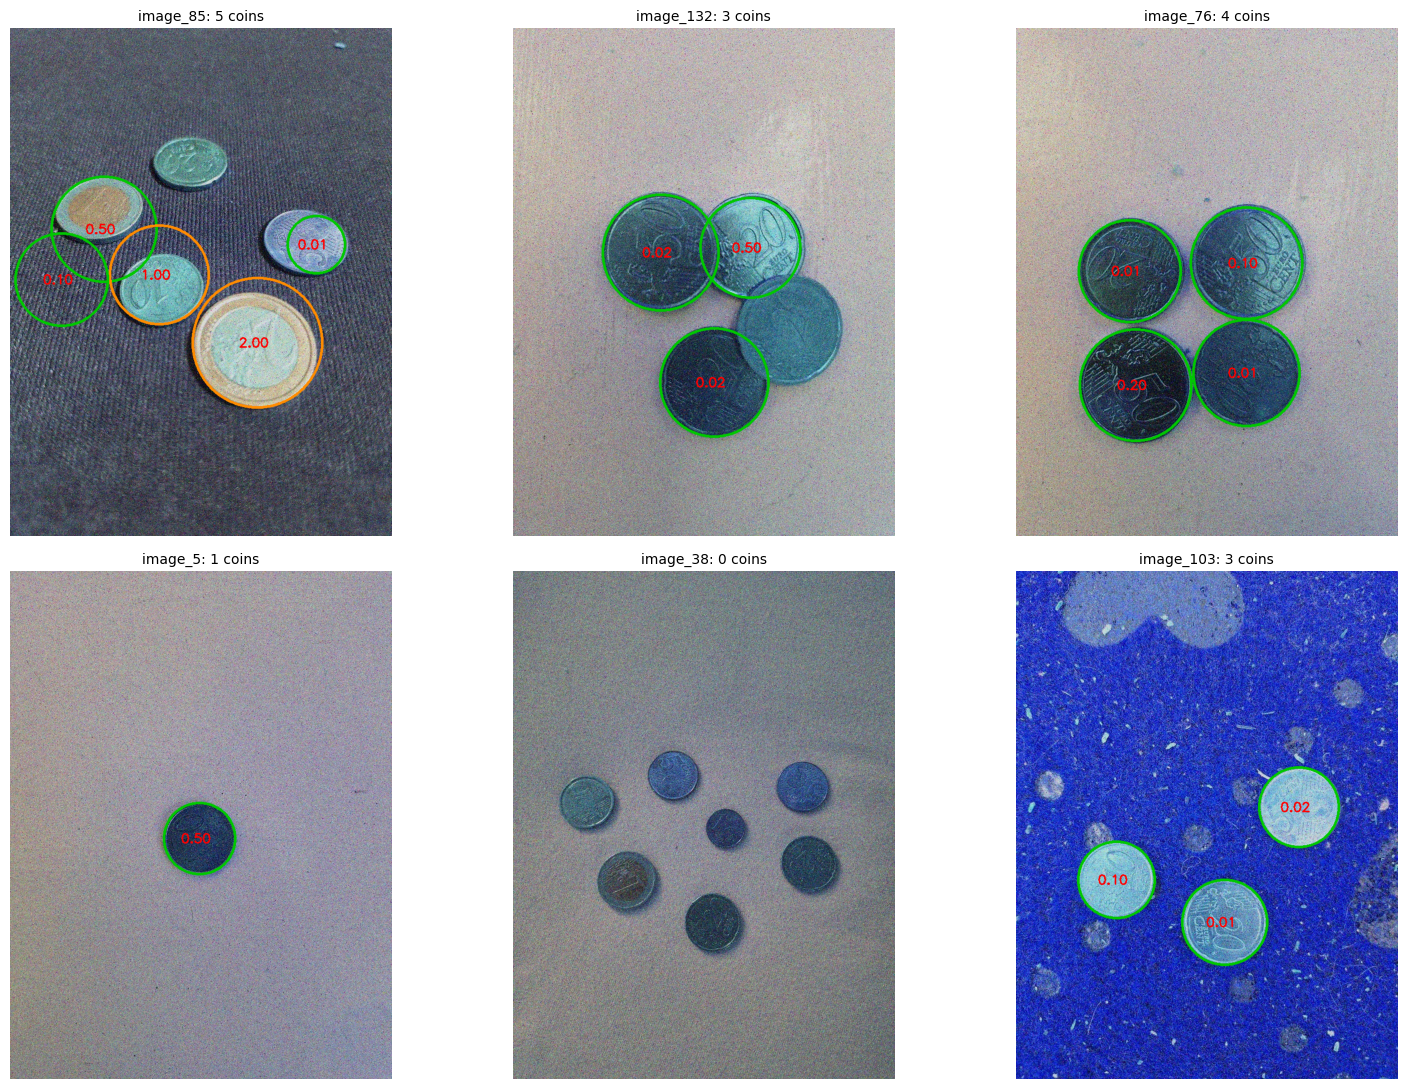

In [7]:
SHOW = ["image_85", "image_132", "image_76", "image_5", "image_38", "image_103"]
vis_list, titles = [], []
for nm in SHOW:
    bgr = cv2.imread(str(TGT / f"{nm}.jpg")); coins = detect_coins(bgr); dens = classify(bgr, coins) if coins else []
    vis = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    for (cx, cy, r), d in zip(coins, dens):
        col = (255, 140, 0) if d in BIMETAL else (0, 200, 0)
        cv2.circle(vis, (cx, cy), r, col, 3); cv2.putText(vis, f"{VALUE_EUR[d]:.2f}", (cx-35, cy+8),
                                                           cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)
    vis_list.append(vis); titles.append(f"{nm}: {len(coins)} coins")
show_grid(vis_list, titles, ncols=3, figsize=(16, 11))

### What is solid vs approximate (see `DECISIONS.md`)

| Stage | Status | Evidence |
|---|---|---|
| Detection (normal images) | **solid** | exact counts, ~0 background FP (Hough, DEC-5) |
| Weak-rim recovery | partial | ~21/28 at ~3 FP on the validation set (overshoot + GHT-confidence gate, DEC-13) |
| Bi-metal flag (1€/2€) | **solid** | chroma-ring separates the references cleanly and flags the euros on targets (DEC-14) |
| Mono denomination (number) | **approximate** | fair GHT ~4/8 on a small hand-read GT (DEC-12); cast + wear + low-res defeat appearance matching |

**Why classification is hard (root cause).** The discriminative digit is a small fraction of a
common-side design *shared across denominations*, and the blue specular cast + wear + low resolution
wash out the relief; reading it reliably needs learned OCR, which the brief forbids. We therefore
report a **well-justified partial** result, as the evaluation criteria prefer.